# To Predict the Resturant Ratings

## Load Dataset

In [50]:
import pandas as pd
df=pd.read_csv("Dataset.csv")

In [51]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [52]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [53]:
df.shape

(9551, 21)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

## EDA 

In [55]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [56]:
df = df.dropna(subset=['Cuisines']) #Dropping the missing 9 rows 

## Data visualization

In [57]:
df["Aggregate rating"].describe()

count    9542.000000
mean        2.665238
std         1.516588
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

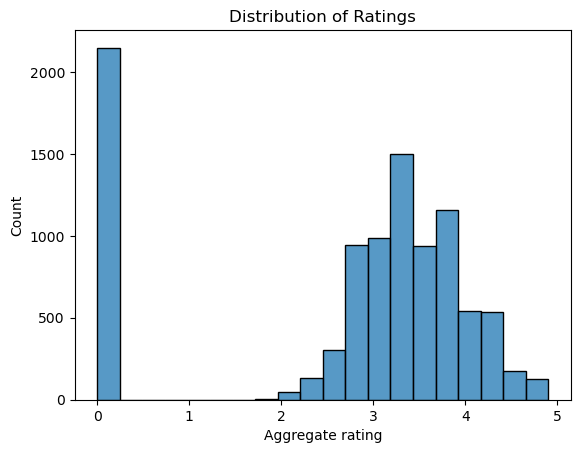

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Aggregate rating"], bins=20)
plt.title("Distribution of Ratings")
plt.show()

In [59]:
#removed 0 ratings
df = df[df["Aggregate rating"] > 0] 

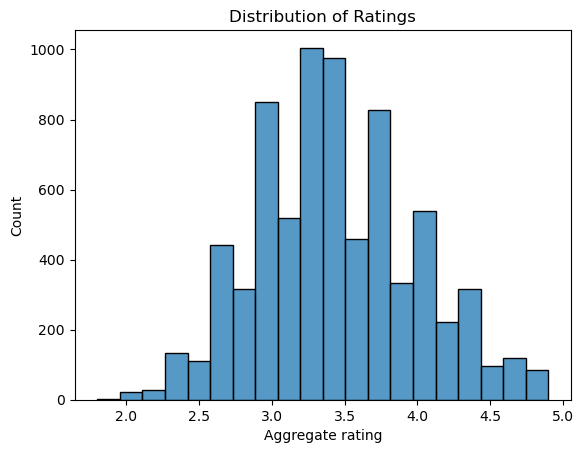

In [60]:
sns.histplot(df["Aggregate rating"], bins=20)
plt.title("Distribution of Ratings")
plt.show()

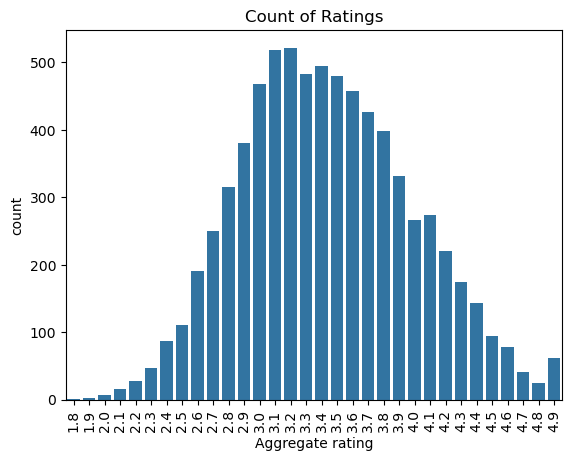

In [61]:
#Count of resturants by rating
sns.countplot(x="Aggregate rating", data=df)
plt.xticks(rotation=90)
plt.title("Count of Ratings")
plt.show()

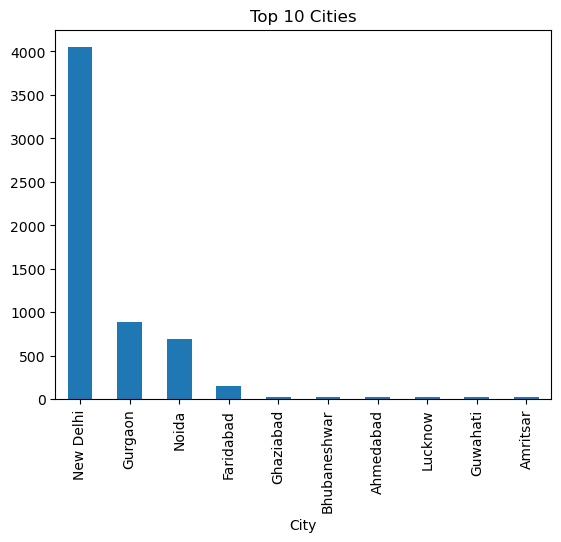

In [62]:
#  Top cities with most resturants
df["City"].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Cities")
plt.show()

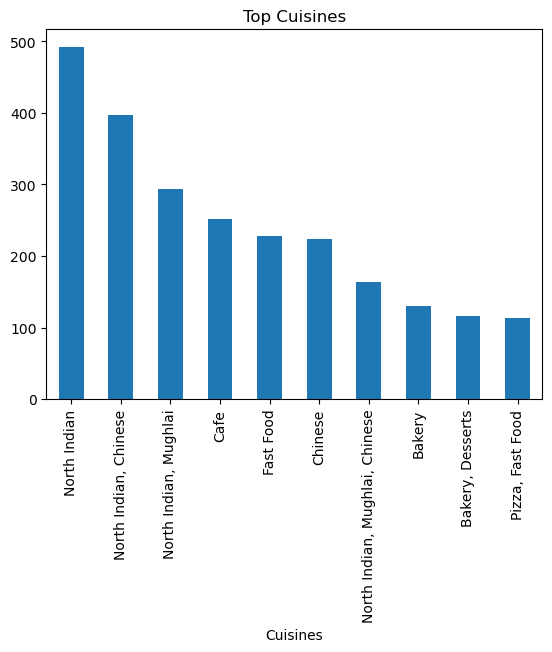

In [63]:
# Top Cusisines
df["Cuisines"].value_counts().head(10).plot(kind='bar')
plt.title("Top Cuisines")
plt.show()

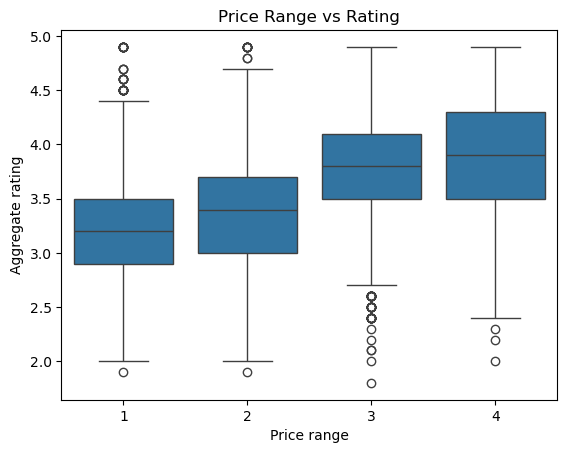

In [64]:
# Price Range vs Rating
sns.boxplot(x="Price range", y="Aggregate rating", data=df)
plt.title("Price Range vs Rating")
plt.show()

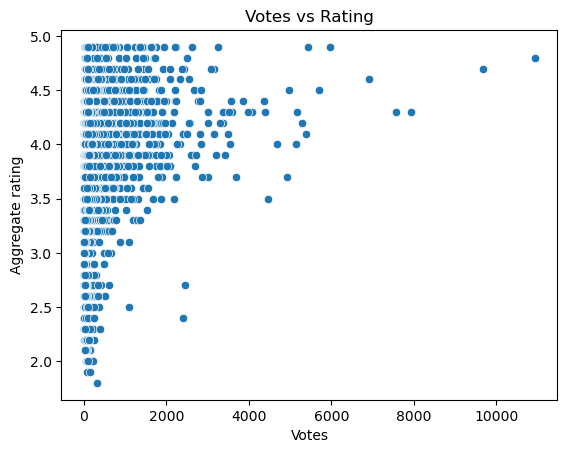

In [65]:
#Votes vs Rating
sns.scatterplot(x="Votes", y="Aggregate rating", data=df)
plt.title("Votes vs Rating")
plt.show()

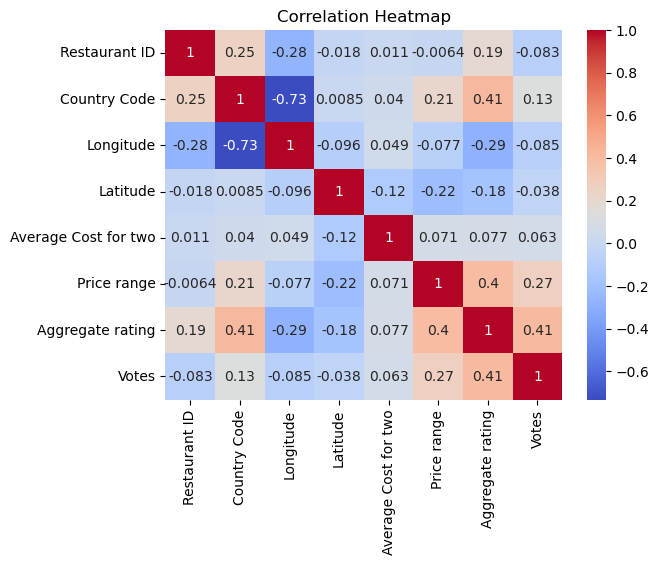

In [66]:
# Correlation Heatmap
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

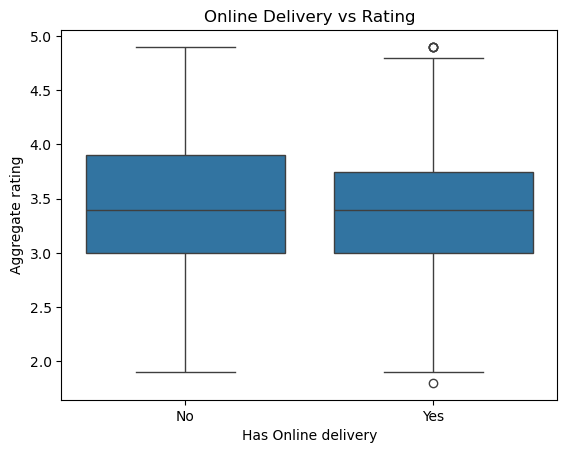

In [67]:
#Online Delivery Impact
sns.boxplot(x="Has Online delivery", y="Aggregate rating", data=df)
plt.title("Online Delivery vs Rating")
plt.show()

## Pre-Processing 

In [68]:
df = df.drop(["Restaurant Name", "Address", "Locality", "Currency","Restaurant ID","Country Code", "Longitude", "Latitude"], axis=1)

In [69]:
X = df.drop("Aggregate rating", axis=1)
y = df["Aggregate rating"]

## Train-Test Split

In [76]:
from sklearn.model_selection import train_test_split
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Selection and training

In [78]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Evaluation

In [79]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression Results:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MSE: 0.05078426649746016
R2 Score: 0.8359796516865778


## Insights

## From my analysis, I found that votes and price range are the most influential factors affecting restaurant ratings.
## Restaurants with higher customer engagement and premium pricing tend to have better ratings.
## I also observed that location has minimal impact, and removing irrelevant features improved model accuracy significantly.

## Model Saving

In [82]:
import joblib

joblib.dump(lr, "restaurant_rating_model.pkl")

['restaurant_rating_model.pkl']